# Credit Risk Scoring and Early Default Warning System

This notebook performs exploratory data analysis (EDA) for a production-style credit risk scoring and early default warning system using the Home Credit Default Risk dataset.

The objective is to understand borrower profiles, data quality, class imbalance, missing values, and early risk signals before any preprocessing or model training is implemented.

## Target Definition

- `TARGET = 0`: Client had no payment difficulty.
- `TARGET = 1`: Client had payment difficulty and represents elevated default risk.

## Data Handling Rules

- Raw CSV files in `data/raw` are read-only inputs.
- No manual CSV cleaning or raw data modification is performed.
- No cleaned or transformed datasets are saved in this notebook.
- Generated plots are saved only to `reports/figures`.

## 1. Import Libraries

In [19]:
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data" / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## 2. Define Paths and Load Raw Data

Only files from `data/raw` are loaded. Figures are saved to `reports/figures`.

In [20]:
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

APPLICATION_TRAIN_PATH = RAW_DATA_DIR / "application_train.csv"
COLUMNS_DESCRIPTION_PATH = RAW_DATA_DIR / "HomeCredit_columns_description.csv"

application_train = pd.read_csv(APPLICATION_TRAIN_PATH)
columns_description = pd.read_csv(COLUMNS_DESCRIPTION_PATH, encoding="ISO-8859-1")

print(f"Loaded application_train.csv from: {APPLICATION_TRAIN_PATH}")
print(f"Loaded HomeCredit_columns_description.csv from: {COLUMNS_DESCRIPTION_PATH}")

Loaded application_train.csv from: C:\credit-risk-early-warning-system\data\raw\application_train.csv
Loaded HomeCredit_columns_description.csv from: C:\credit-risk-early-warning-system\data\raw\HomeCredit_columns_description.csv


## 3. Dataset Overview

This section checks the dataset size, sample records, column types, duplicate rows, and target distribution before any modeling work.

In [21]:
print("application_train.csv shape:")
print(application_train.shape)

print("\nColumn count:")
print(application_train.shape[1])

application_train.csv shape:
(307511, 122)

Column count:
122


In [22]:
application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,...,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,...,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0000,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,...,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0000,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.5559,0.7296,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [23]:
data_type_summary = (
    application_train.dtypes
    .value_counts()
    .rename_axis("data_type")
    .reset_index(name="column_count")
)

data_type_summary

,data_type,column_count
0,float64,65
1,int64,41
2,object,16


In [24]:
duplicate_row_count = application_train.duplicated().sum()
print(f"Duplicate row count: {duplicate_row_count}")

Duplicate row count: 0


In [25]:
target_counts = application_train["TARGET"].value_counts().sort_index()
target_percentages = application_train["TARGET"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame(
    {
        "count": target_counts,
        "percentage": target_percentages.round(2),
    }
)

target_summary

,count,percentage
TARGET,,
0,282686,91.9300
1,24825,8.0700


## 4. Target Distribution

Credit default data is usually imbalanced because most borrowers do not default. This means plain accuracy is not enough: a model could predict the majority class for nearly every applicant and still look accurate while failing to identify high-risk borrowers.

Later modeling should therefore evaluate metrics such as recall, precision, F1-score, ROC-AUC, PR-AUC, and business cost-sensitive thresholds instead of relying only on accuracy.

In [26]:
print("TARGET counts:")
print(target_counts)

print("\nTARGET percentages:")
print(target_percentages.round(2).astype(str) + "%")

TARGET counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET percentages:
TARGET
0    91.93%
1     8.07%
Name: proportion, dtype: object


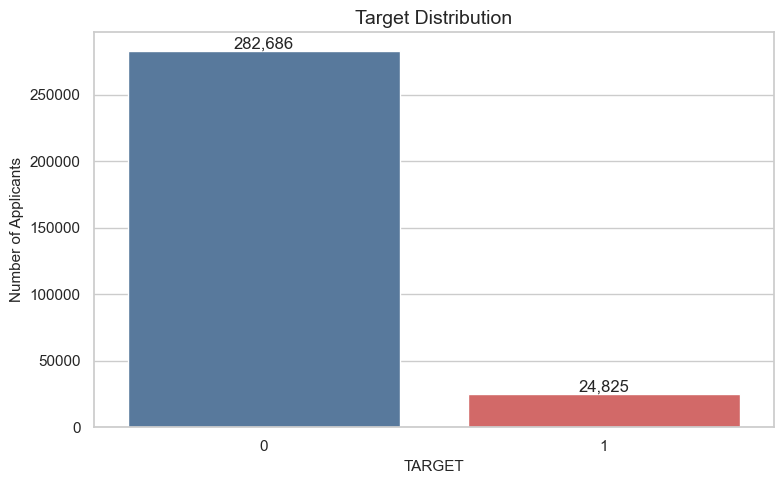

Saved figure to: C:\credit-risk-early-warning-system\reports\figures\target_distribution.png


In [27]:
target_plot_path = FIGURES_DIR / "target_distribution.png"

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    x=target_counts.index.astype(str),
    y=target_counts.values,
    hue=target_counts.index.astype(str),
    palette=["#4C78A8", "#E45756"],
    legend=False,
    ax=ax,
)
ax.set_title("Target Distribution")
ax.set_xlabel("TARGET")
ax.set_ylabel("Number of Applicants")

for index, value in enumerate(target_counts.values):
    ax.text(index, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(target_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {target_plot_path}")

## 5. Missing Values

Missing values are important in finance data because they can reflect incomplete applications, unavailable external bureau records, non-applicable fields, reporting gaps, or operational data collection issues. Missingness itself may carry predictive signal, but it must be handled carefully to avoid biased decisions and unstable model behavior.

In [28]:
missing_values = application_train.isna().sum()
missing_percentages = application_train.isna().mean() * 100

missing_summary = (
    pd.DataFrame(
        {
            "missing_count": missing_values,
            "missing_percentage": missing_percentages.round(2),
        }
    )
    .sort_values("missing_percentage", ascending=False)
)

missing_summary.head(30)

,missing_count,missing_percentage
COMMONAREA_AVG,214865,69.8700
COMMONAREA_MODE,214865,69.8700
COMMONAREA_MEDI,214865,69.8700
NONLIVINGAPARTMENTS_MEDI,213514,69.4300
NONLIVINGAPARTMENTS_MODE,213514,69.4300
NONLIVINGAPARTMENTS_AVG,213514,69.4300
FONDKAPREMONT_MODE,210295,68.3900
LIVINGAPARTMENTS_AVG,210199,68.3500
LIVINGAPARTMENTS_MEDI,210199,68.3500
LIVINGAPARTMENTS_MODE,210199,68.3500


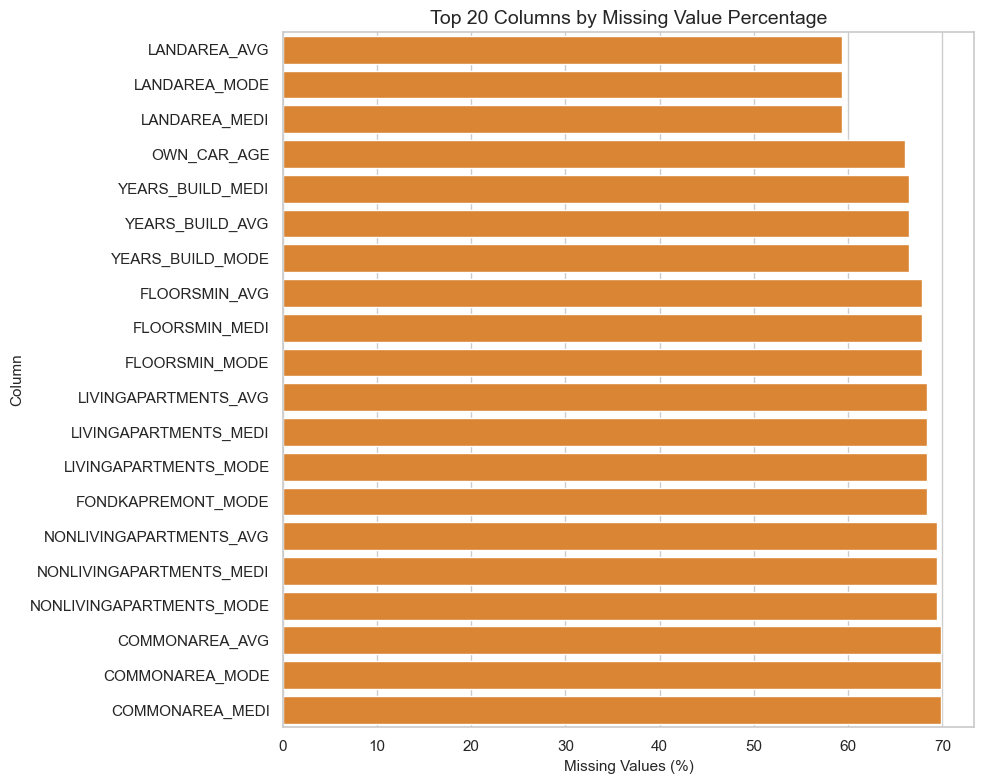

Saved figure to: C:\credit-risk-early-warning-system\reports\figures\missing_values_top20.png


In [29]:
missing_plot_path = FIGURES_DIR / "missing_values_top20.png"
top20_missing = missing_summary.head(20).sort_values("missing_percentage", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    x=top20_missing["missing_percentage"],
    y=top20_missing.index,
    color="#F58518",
    ax=ax,
)
ax.set_title("Top 20 Columns by Missing Value Percentage")
ax.set_xlabel("Missing Values (%)")
ax.set_ylabel("Column")
plt.tight_layout()
plt.savefig(missing_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {missing_plot_path}")

## 6. Numerical Feature Analysis

The following financial and borrower-history fields are reviewed when present in the dataset:

- `AMT_INCOME_TOTAL`
- `AMT_CREDIT`
- `AMT_ANNUITY`
- `AMT_GOODS_PRICE`
- `DAYS_BIRTH`
- `DAYS_EMPLOYED`

These variables can help explain repayment capacity, loan size, installment burden, collateral or goods value, applicant age, and employment history.

In [30]:
numerical_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
]

available_numerical_features = [col for col in numerical_features if col in application_train.columns]
missing_numerical_features = sorted(set(numerical_features) - set(available_numerical_features))

print("Available numerical features:", available_numerical_features)
print("Missing numerical features:", missing_numerical_features)

Available numerical features: ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED']
Missing numerical features: []


In [31]:
application_train[available_numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0000,168797.9193,237123.1463,25650.0000,112500.0000,147150.0000,202500.0000,117000000.0000
AMT_CREDIT,307511.0000,599025.9997,402490.7770,45000.0000,270000.0000,513531.0000,808650.0000,4050000.0000
AMT_ANNUITY,307499.0000,27108.5739,14493.7373,1615.5000,16524.0000,24903.0000,34596.0000,258025.5000
AMT_GOODS_PRICE,307233.0000,538396.2074,369446.4605,40500.0000,238500.0000,450000.0000,679500.0000,4050000.0000
DAYS_BIRTH,307511.0000,-16036.9951,4363.9886,-25229.0000,-19682.0000,-15750.0000,-12413.0000,-7489.0000
DAYS_EMPLOYED,307511.0000,63815.0459,141275.7665,-17912.0000,-2760.0000,-1213.0000,-289.0000,365243.0000


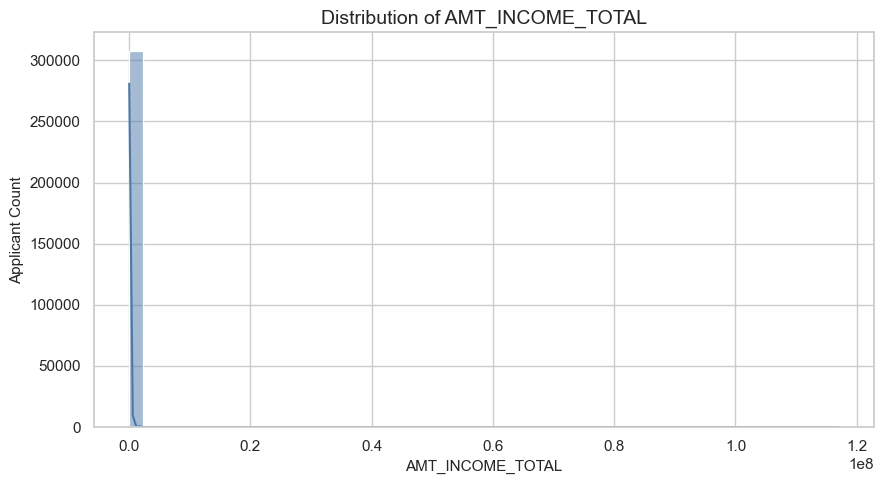

Saved figure to: C:\credit-risk-early-warning-system\reports\figures\numeric_amt_income_total_histogram.png


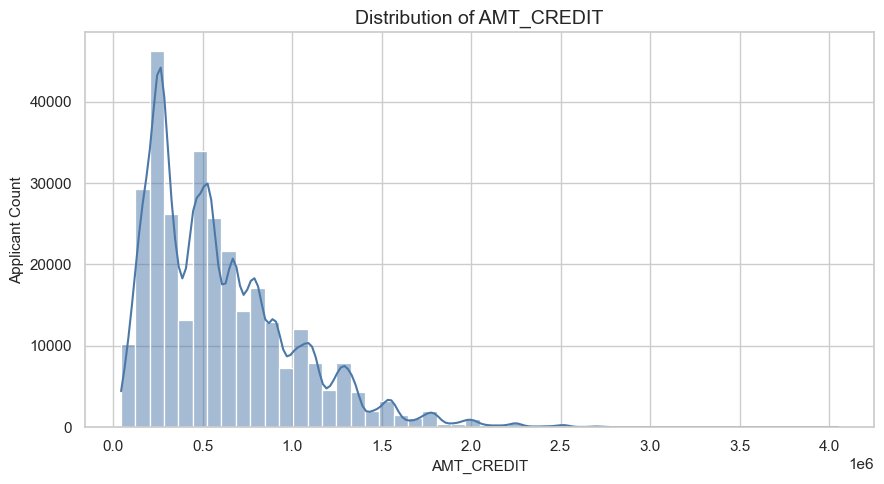

Saved figure to: C:\credit-risk-early-warning-system\reports\figures\numeric_amt_credit_histogram.png


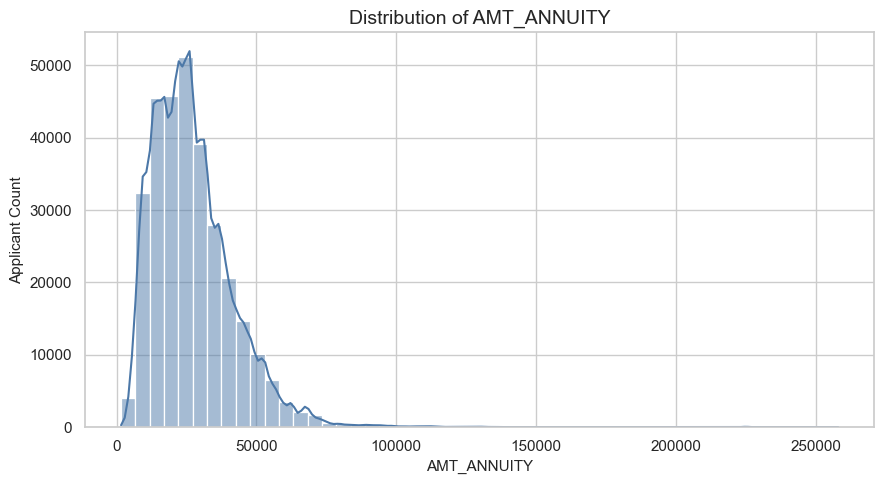

Saved figure to: C:\credit-risk-early-warning-system\reports\figures\numeric_amt_annuity_histogram.png


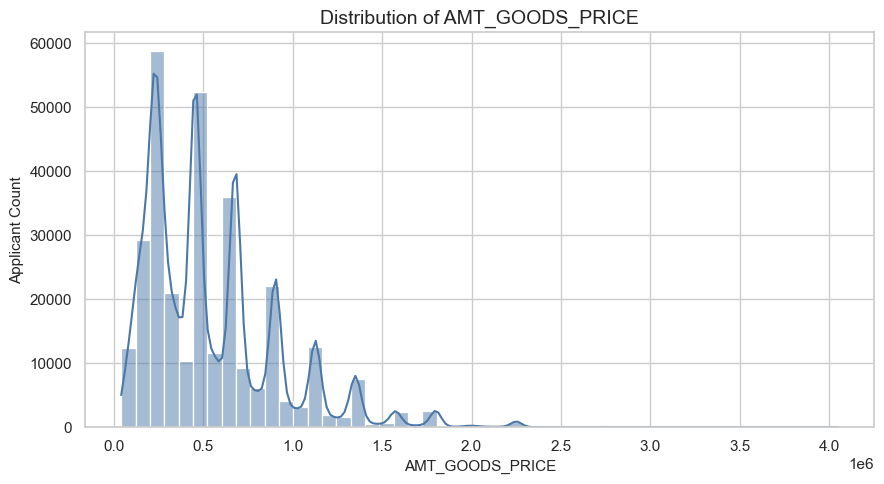

Saved figure to: C:\credit-risk-early-warning-system\reports\figures\numeric_amt_goods_price_histogram.png


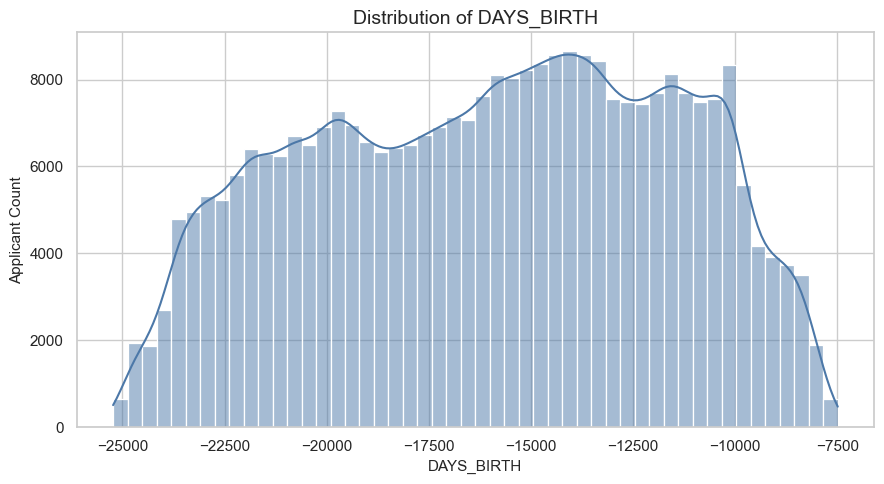

Saved figure to: C:\credit-risk-early-warning-system\reports\figures\numeric_days_birth_histogram.png


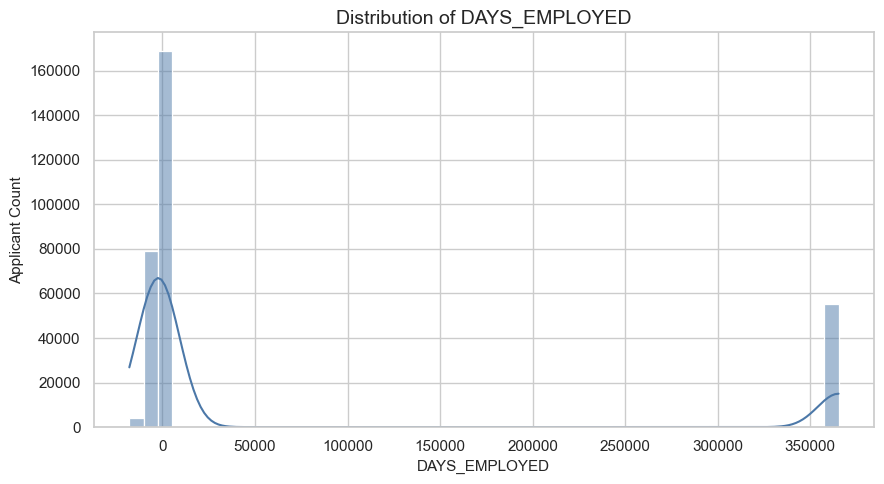

Saved figure to: C:\credit-risk-early-warning-system\reports\figures\numeric_days_employed_histogram.png


In [32]:
for column in available_numerical_features:
    plot_path = FIGURES_DIR / f"numeric_{column.lower()}_histogram.png"

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.histplot(application_train[column].dropna(), bins=50, kde=True, color="#4C78A8", ax=ax)
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Applicant Count")
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved figure to: {plot_path}")

## 7. Categorical Feature Analysis

Categorical features are examined for applicant mix and observed default rate. These views are useful for identifying risk segmentation patterns, but they should not be interpreted as causal effects without further analysis.

In [33]:
categorical_features = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
]

available_categorical_features = [col for col in categorical_features if col in application_train.columns]
missing_categorical_features = sorted(set(categorical_features) - set(available_categorical_features))

print("Available categorical features:", available_categorical_features)
print("Missing categorical features:", missing_categorical_features)

Available categorical features: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']
Missing categorical features: []


Categorical feature: NAME_CONTRACT_TYPE


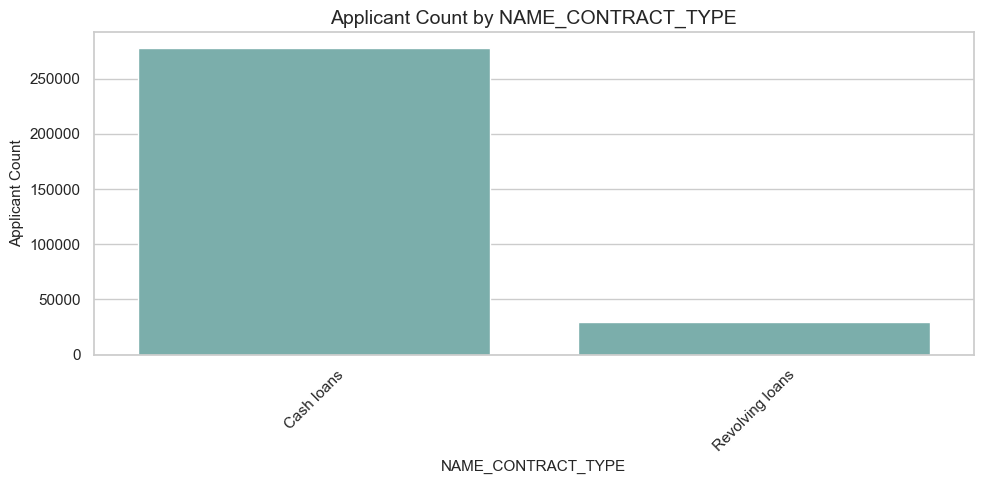

,applicant_count,default_count,default_rate,default_rate_percentage
NAME_CONTRACT_TYPE,,,,
Cash loans,278232,23221,0.0835,8.3500
Revolving loans,29279,1604,0.0548,5.4800


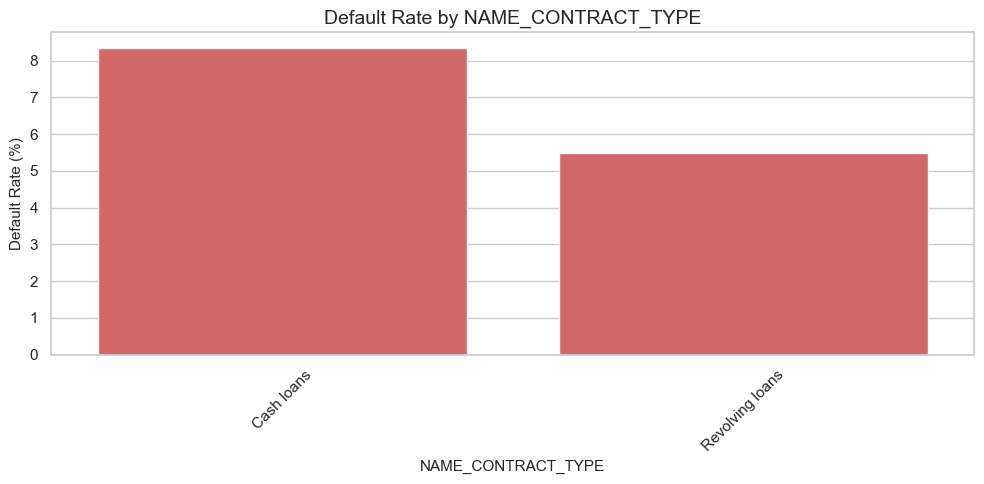

Saved count plot to: C:\credit-risk-early-warning-system\reports\figures\categorical_name_contract_type_count.png
Saved default rate plot to: C:\credit-risk-early-warning-system\reports\figures\categorical_name_contract_type_default_rate.png
Categorical feature: CODE_GENDER


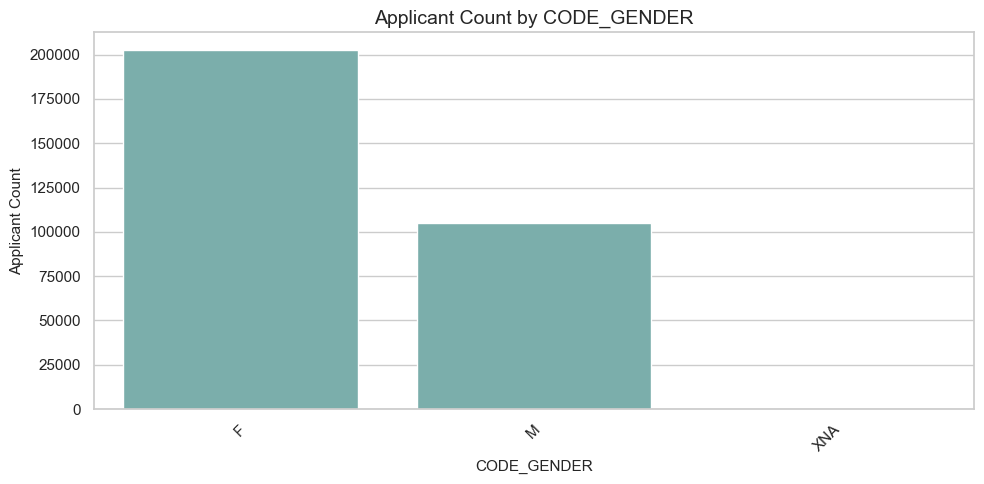

,applicant_count,default_count,default_rate,default_rate_percentage
CODE_GENDER,,,,
M,105059,10655,0.1014,10.1400
F,202448,14170,0.0700,7.0000
XNA,4,0,0.0000,0.0000


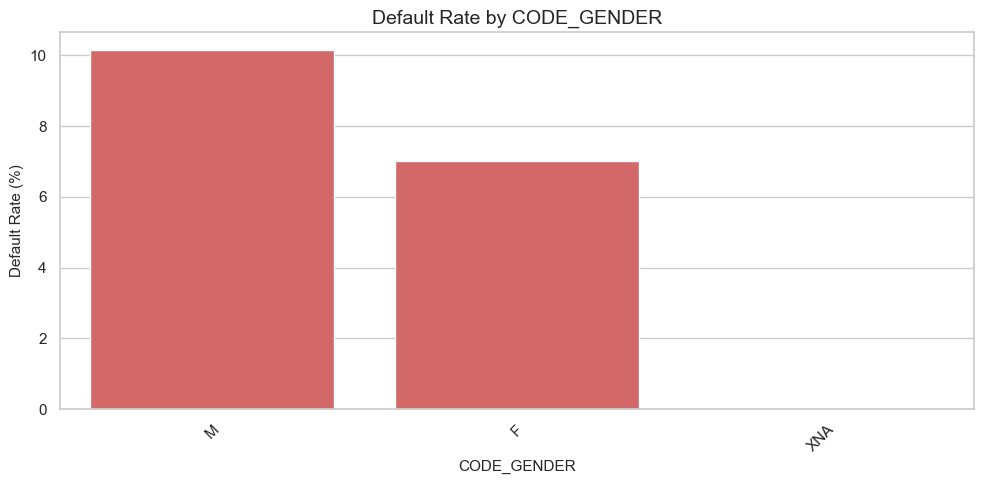

Saved count plot to: C:\credit-risk-early-warning-system\reports\figures\categorical_code_gender_count.png
Saved default rate plot to: C:\credit-risk-early-warning-system\reports\figures\categorical_code_gender_default_rate.png
Categorical feature: FLAG_OWN_CAR


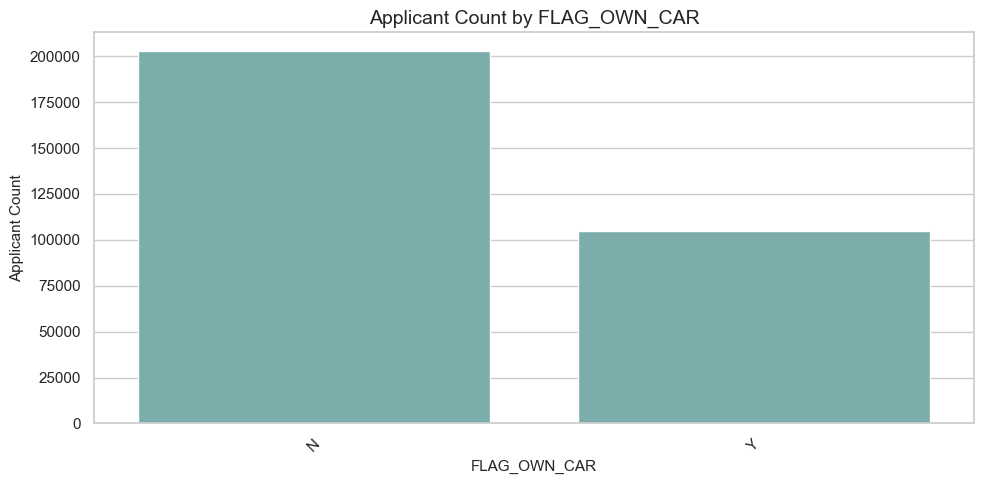

,applicant_count,default_count,default_rate,default_rate_percentage
FLAG_OWN_CAR,,,,
N,202924,17249,0.0850,8.5000
Y,104587,7576,0.0724,7.2400


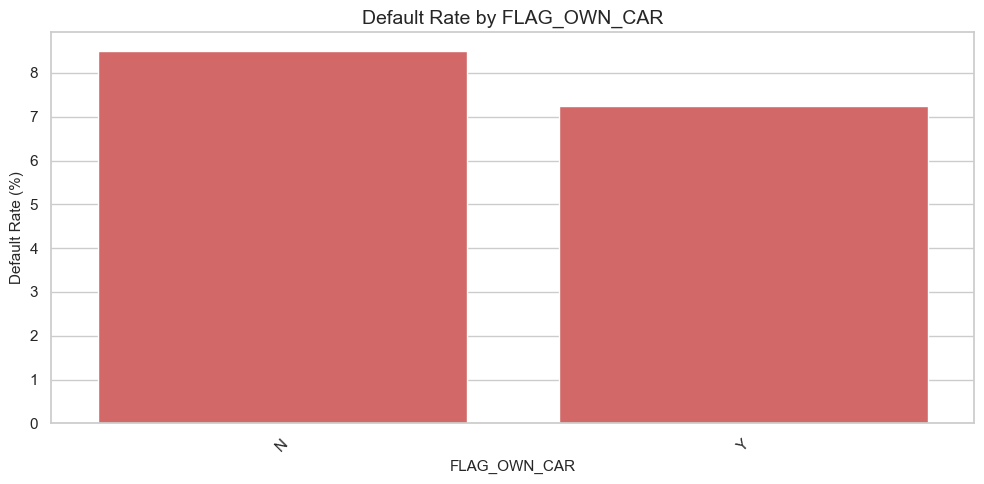

Saved count plot to: C:\credit-risk-early-warning-system\reports\figures\categorical_flag_own_car_count.png
Saved default rate plot to: C:\credit-risk-early-warning-system\reports\figures\categorical_flag_own_car_default_rate.png
Categorical feature: FLAG_OWN_REALTY


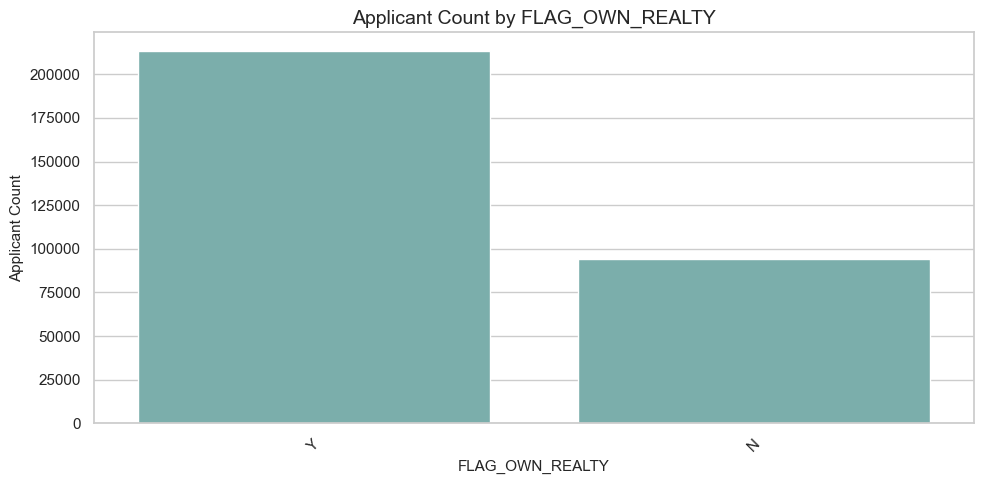

,applicant_count,default_count,default_rate,default_rate_percentage
FLAG_OWN_REALTY,,,,
N,94199,7842,0.0832,8.3200
Y,213312,16983,0.0796,7.9600


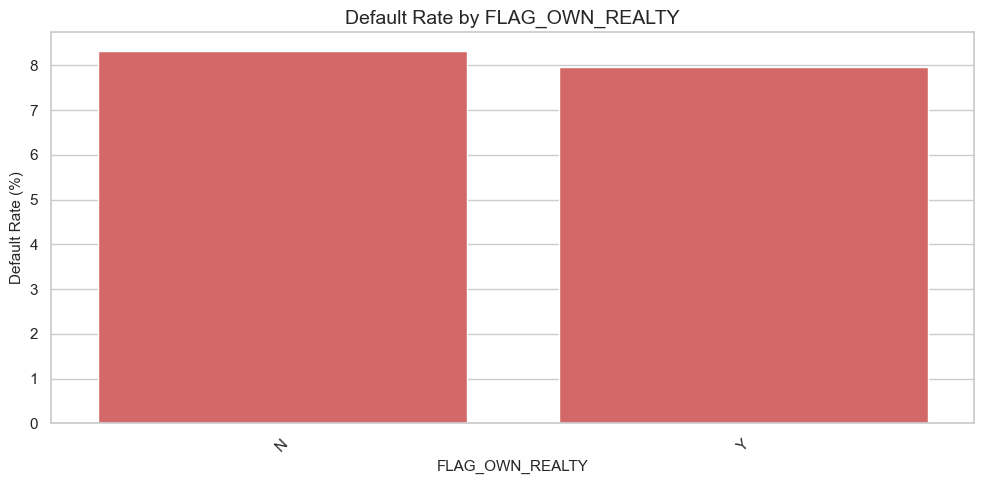

Saved count plot to: C:\credit-risk-early-warning-system\reports\figures\categorical_flag_own_realty_count.png
Saved default rate plot to: C:\credit-risk-early-warning-system\reports\figures\categorical_flag_own_realty_default_rate.png
Categorical feature: NAME_EDUCATION_TYPE


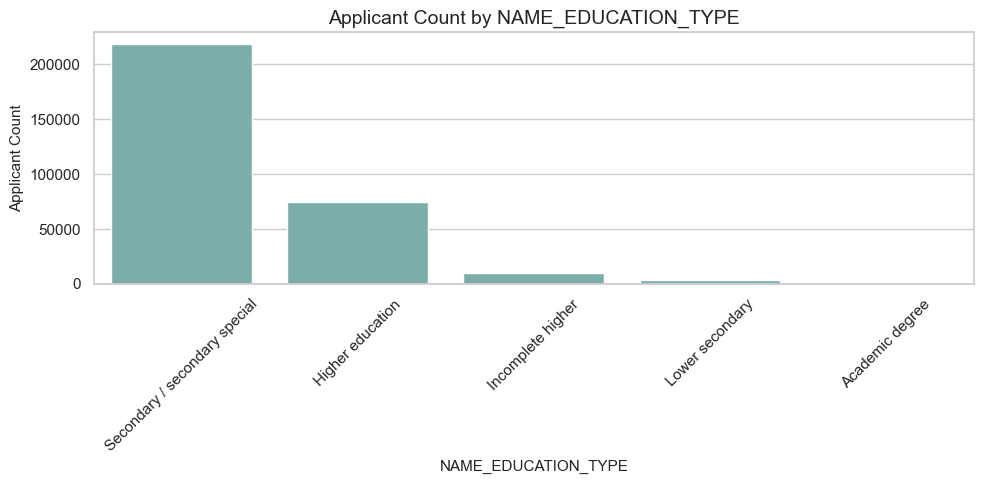

,applicant_count,default_count,default_rate,default_rate_percentage
NAME_EDUCATION_TYPE,,,,
Lower secondary,3816,417,0.1093,10.9300
Secondary / secondary special,218391,19524,0.0894,8.9400
Incomplete higher,10277,872,0.0848,8.4800
Higher education,74863,4009,0.0536,5.3600
Academic degree,164,3,0.0183,1.8300


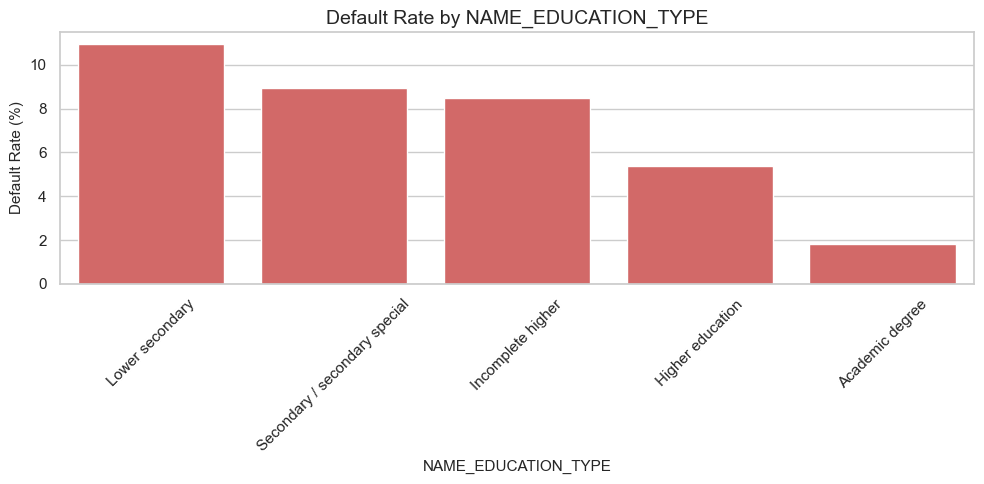

Saved count plot to: C:\credit-risk-early-warning-system\reports\figures\categorical_name_education_type_count.png
Saved default rate plot to: C:\credit-risk-early-warning-system\reports\figures\categorical_name_education_type_default_rate.png
Categorical feature: NAME_FAMILY_STATUS


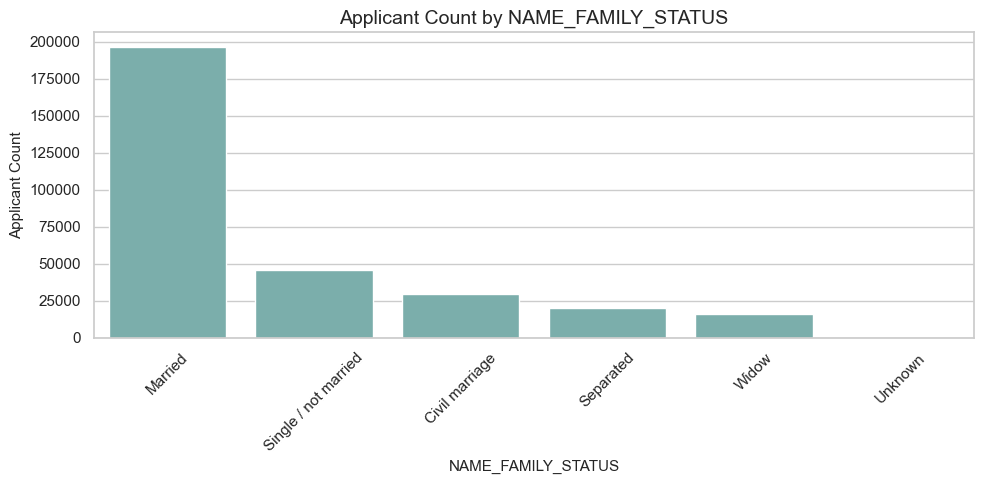

,applicant_count,default_count,default_rate,default_rate_percentage
NAME_FAMILY_STATUS,,,,
Civil marriage,29775,2961,0.0994,9.9400
Single / not married,45444,4457,0.0981,9.8100
Separated,19770,1620,0.0819,8.1900
Married,196432,14850,0.0756,7.5600
Widow,16088,937,0.0582,5.8200
Unknown,2,0,0.0000,0.0000


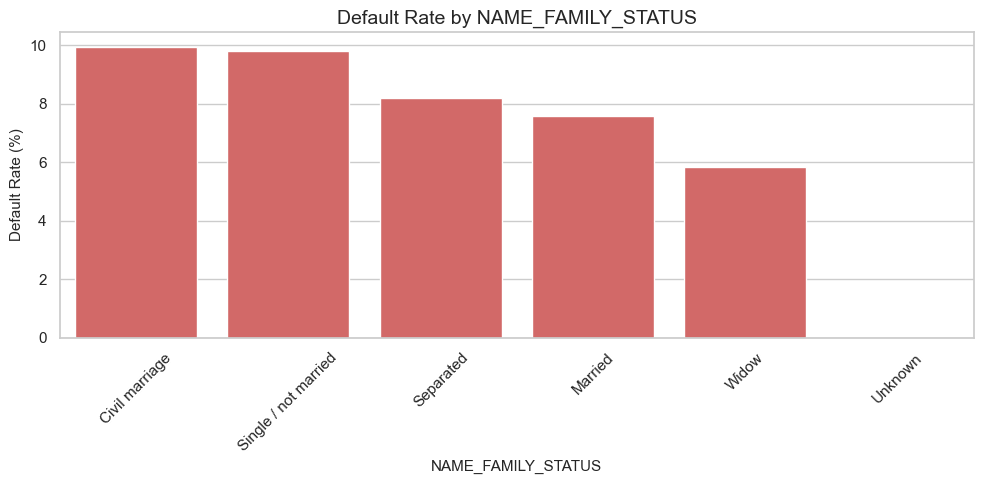

Saved count plot to: C:\credit-risk-early-warning-system\reports\figures\categorical_name_family_status_count.png
Saved default rate plot to: C:\credit-risk-early-warning-system\reports\figures\categorical_name_family_status_default_rate.png
Categorical feature: NAME_HOUSING_TYPE


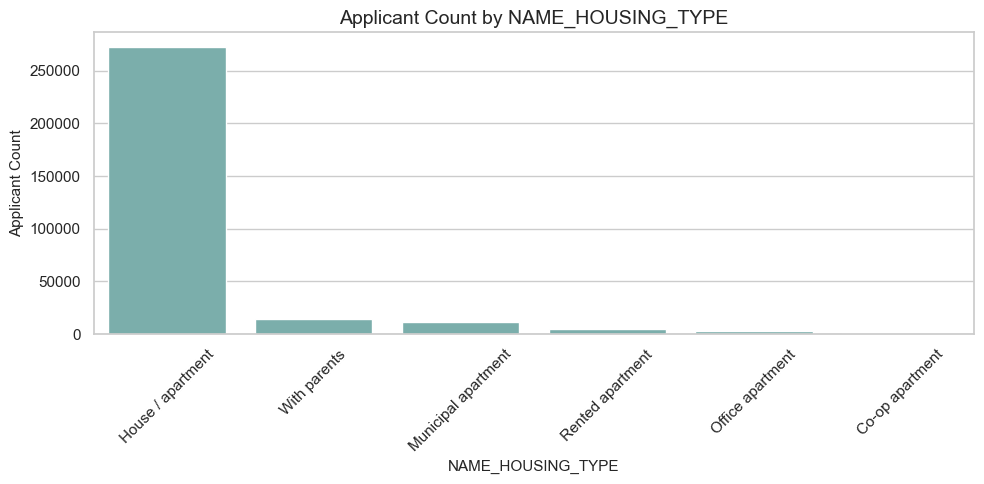

,applicant_count,default_count,default_rate,default_rate_percentage
NAME_HOUSING_TYPE,,,,
Rented apartment,4881,601,0.1231,12.3100
With parents,14840,1736,0.1170,11.7000
Municipal apartment,11183,955,0.0854,8.5400
Co-op apartment,1122,89,0.0793,7.9300
House / apartment,272868,21272,0.0780,7.8000
Office apartment,2617,172,0.0657,6.5700


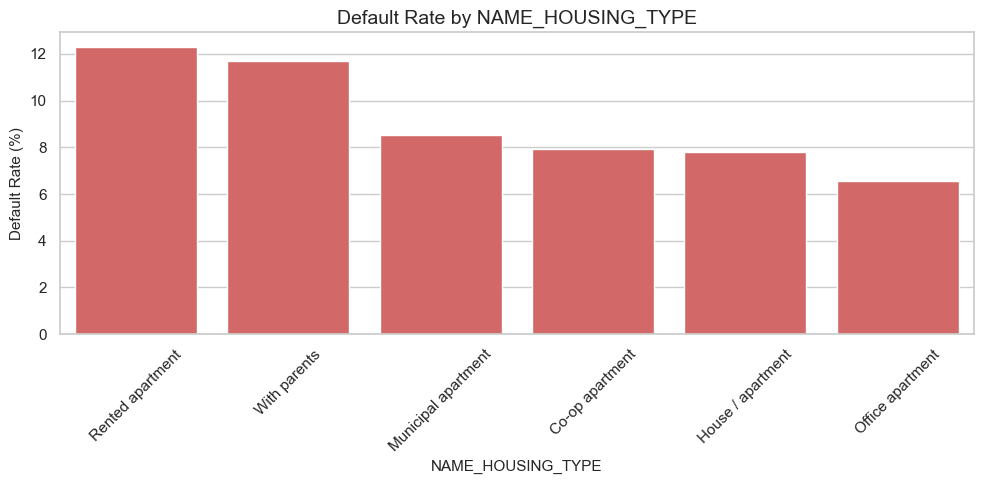

Saved count plot to: C:\credit-risk-early-warning-system\reports\figures\categorical_name_housing_type_count.png
Saved default rate plot to: C:\credit-risk-early-warning-system\reports\figures\categorical_name_housing_type_default_rate.png


In [34]:
for column in available_categorical_features:
    print("=" * 100)
    print(f"Categorical feature: {column}")

    count_plot_path = FIGURES_DIR / f"categorical_{column.lower()}_count.png"
    default_rate_plot_path = FIGURES_DIR / f"categorical_{column.lower()}_default_rate.png"

    order = application_train[column].value_counts(dropna=False).index

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.countplot(
        data=application_train,
        x=column,
        order=order,
        color="#72B7B2",
        ax=ax,
    )
    ax.set_title(f"Applicant Count by {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Applicant Count")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig(count_plot_path, dpi=150, bbox_inches="tight")
    plt.show()

    default_rate_table = (
        application_train.groupby(column, dropna=False)["TARGET"]
        .agg(applicant_count="count", default_count="sum", default_rate="mean")
        .sort_values("default_rate", ascending=False)
    )
    default_rate_table["default_rate_percentage"] = (default_rate_table["default_rate"] * 100).round(2)
    display(default_rate_table)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        x=default_rate_table.index.astype(str),
        y=default_rate_table["default_rate_percentage"],
        color="#E45756",
        ax=ax,
    )
    ax.set_title(f"Default Rate by {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Default Rate (%)")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig(default_rate_plot_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved count plot to: {count_plot_path}")
    print(f"Saved default rate plot to: {default_rate_plot_path}")

## 8. Correlation Analysis

This section calculates correlations between numeric features and `TARGET`. Correlation is a quick screening tool, not a final feature-importance method. It only captures linear relationships and can miss nonlinear risk signals.

In [35]:
numeric_columns = application_train.select_dtypes(include=[np.number]).columns
target_correlations = (
    application_train[numeric_columns]
    .corr()["TARGET"]
    .drop(labels="TARGET")
    .dropna()
    .sort_values(ascending=False)
)

top20_positive_correlations = target_correlations.head(20)
top20_negative_correlations = target_correlations.tail(20).sort_values(ascending=True)

print("Top 20 positive correlations with TARGET:")
display(top20_positive_correlations.to_frame("correlation_with_target"))

print("Top 20 negative correlations with TARGET:")
display(top20_negative_correlations.to_frame("correlation_with_target"))

Top 20 positive correlations with TARGET:


,correlation_with_target
DAYS_BIRTH,0.0782
REGION_RATING_CLIENT_W_CITY,0.0609
REGION_RATING_CLIENT,0.0589
DAYS_LAST_PHONE_CHANGE,0.0552
DAYS_ID_PUBLISH,0.0515
REG_CITY_NOT_WORK_CITY,0.0510
FLAG_EMP_PHONE,0.0460
REG_CITY_NOT_LIVE_CITY,0.0444
FLAG_DOCUMENT_3,0.0443
DAYS_REGISTRATION,0.0420


Top 20 negative correlations with TARGET:


,correlation_with_target
EXT_SOURCE_3,-0.1789
EXT_SOURCE_2,-0.1605
EXT_SOURCE_1,-0.1553
DAYS_EMPLOYED,-0.0449
FLOORSMAX_AVG,-0.0440
FLOORSMAX_MEDI,-0.0438
FLOORSMAX_MODE,-0.0432
AMT_GOODS_PRICE,-0.0396
REGION_POPULATION_RELATIVE,-0.0372
ELEVATORS_AVG,-0.0342


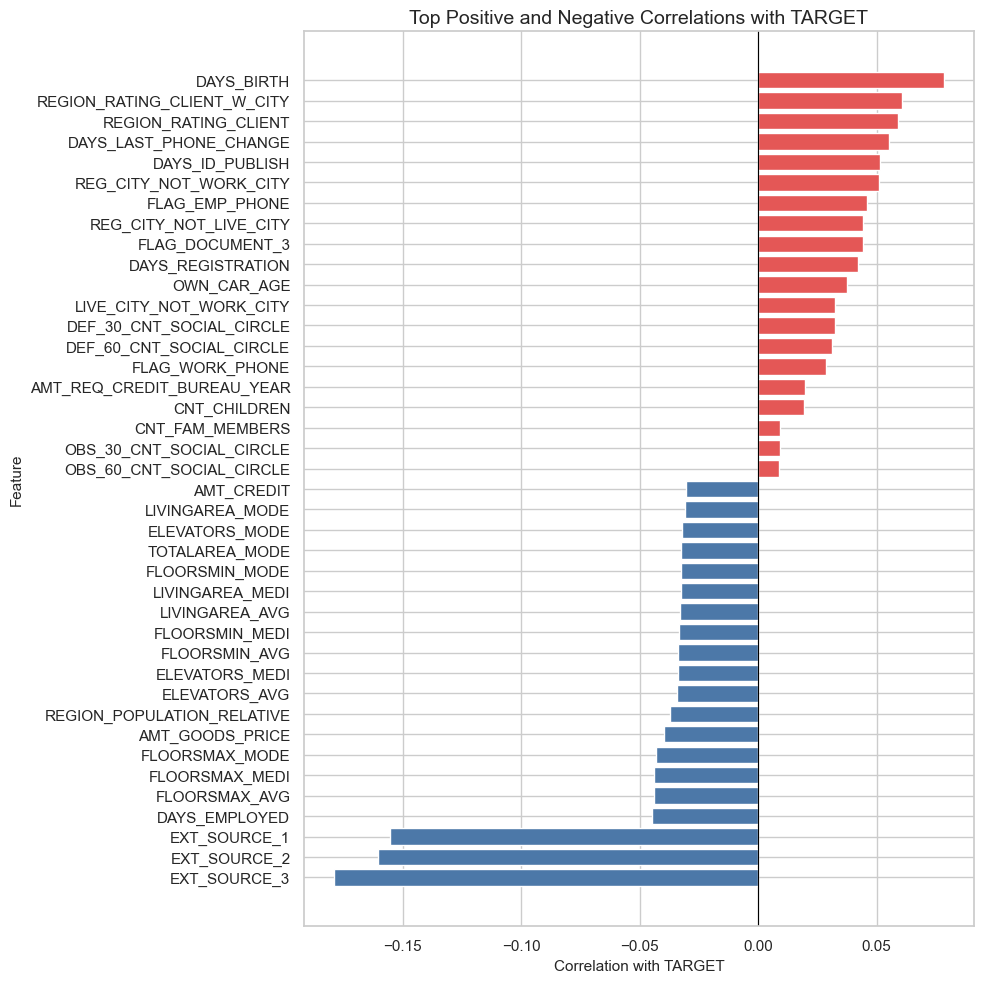

Saved figure to: C:\credit-risk-early-warning-system\reports\figures\target_correlation_top20.png


In [36]:
correlation_plot_path = FIGURES_DIR / "target_correlation_top20.png"
top_correlations_for_plot = pd.concat(
    [top20_negative_correlations, top20_positive_correlations]
).sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = np.where(top_correlations_for_plot.values >= 0, "#E45756", "#4C78A8")
ax.barh(top_correlations_for_plot.index, top_correlations_for_plot.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top Positive and Negative Correlations with TARGET")
ax.set_xlabel("Correlation with TARGET")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(correlation_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {correlation_plot_path}")

## 9. Business Insights

- The target is highly imbalanced: most applicants do not show payment difficulty, while the default-risk group is much smaller and more business-critical.
- Missing values are a major data-quality challenge and may represent unavailable bureau information, non-applicable applicant fields, or operational collection gaps.
- Financial columns such as income, credit amount, annuity amount, and goods price are central to repayment-capacity analysis and affordability checks.
- Applicant age and employment history fields provide useful behavioral and stability context, but they require careful treatment because they are represented as day offsets.
- Feature engineering will be needed to create stronger risk indicators such as debt-to-income ratios, annuity-to-income ratios, age bands, employment duration, and missingness flags.
- Imbalanced classification handling will be necessary because optimizing for accuracy alone can under-detect risky borrowers and create weak early-warning performance.
- SHAP explainability will be important later because credit risk models need transparent, auditable explanations for model behavior, stakeholder review, and responsible decision support.